In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
sns.set(style="whitegrid", palette="coolwarm")
df = pd.read_csv('/content/crime_dataset_india.csv')
print("Dataset loaded successfully!")
display(df.head())
print("\nShape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()

Dataset loaded successfully!


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00



Shape of dataset: (40160, 14)

Columns:
['Report Number', 'Date Reported', 'Date of Occurrence', 'Time of Occurrence', 'City', 'Crime Code', 'Crime Description', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed', 'Case Closed', 'Date Case Closed']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-n

/tmp/ipython-input-246805935.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


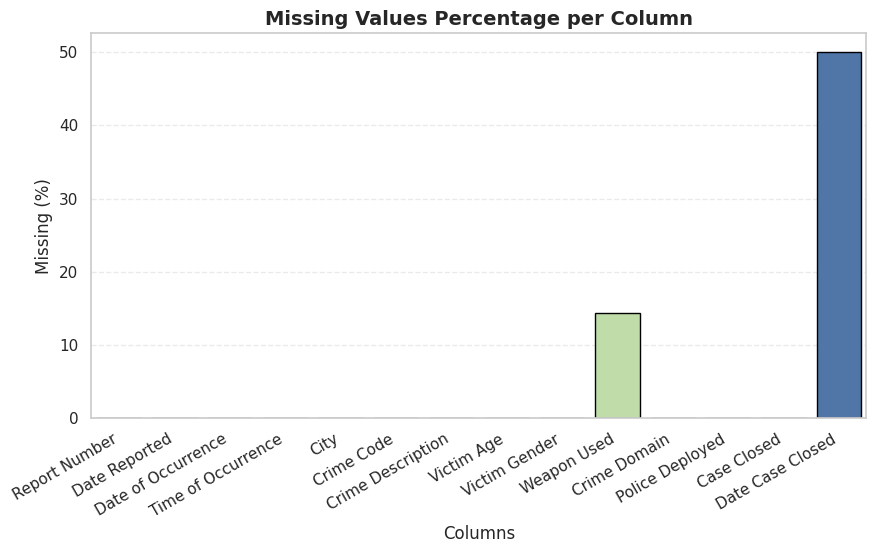

In [7]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

plt.figure(figsize=(10,5))
colors = sns.color_palette("Spectral", len(missing))  # Gradient color palette

sns.barplot(
    x=missing.index,
    y=missing_percent,
    palette=colors,
    edgecolor="black"
)

plt.title("Missing Values Percentage per Column", fontsize=14, fontweight='bold')
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Missing (%)", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


In [30]:
# --- Handle Missing Values ---

# Drop columns with more than 50% missing data
threshold = 0.5
df = df[df.columns[df.isnull().mean() < threshold]].copy() # Use .copy() to avoid SettingWithCopyWarning

# Fill remaining missing values:
#   - numeric columns with median
#   - categorical columns with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0]) # Reassign the result
    else:
        df[col] = df[col].fillna(df[col].median()) # Reassign the result

print("Missing values handled successfully!")
print("\nRemaining Missing Values:\n", df.isnull().sum())

Missing values handled successfully!

Remaining Missing Values:
 Report Number         0
Date Reported         0
Date of Occurrence    0
Time of Occurrence    0
City                  0
Crime Code            0
Victim Age            0
Victim Gender         0
Weapon Used           0
Crime Domain          0
Police Deployed       0
Case Closed           0
Crime_Category        0
dtype: int64


In [32]:
# --- Simplify Crime Description into broader categories ---
if 'Crime Description' in df.columns:
    df['Crime_Category'] = df['Crime Description'].astype(str).apply(
        lambda x: 'Theft' if 'theft' in x.lower()
                  else 'Assault' if 'assault' in x.lower()
                  else 'Fraud' if 'fraud' in x.lower()
                  else 'Other'
    )

    # Drop original Crime Description
    df = df.drop('Crime Description', axis=1)
else:
    print("'Crime Description' column not found. Skipping simplification.")

'Crime Description' column not found. Skipping simplification.


In [48]:
# --- Encode Categorical Columns ---

from sklearn.preprocessing import LabelEncoder

label_encoders = {}
# Select all object type columns, including the newly created 'Crime_Category' and other existing ones
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("All categorical columns encoded successfully.")
print("\nEncoded Columns:\n", list(label_encoders.keys()))


# --- Define Features and Target ---
# Replace 'TargetColumn' with the column you want to predict
X = df.drop('Crime Domain', axis=1)
y = df['Crime Domain']


# --- Split the Dataset ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData split completed:")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

All categorical columns encoded successfully.

Encoded Columns:
 []

Data split completed:
Training set: (32128, 12)
Testing set: (8032, 12)


In [49]:
# --- Scale Features ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --- Train Decision Tree Classifier ---
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       random_state=42)

In [50]:
# --- Make Predictions ---
y_pred = dt_model.predict(X_test)


# --- Evaluate Model ---
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 55.83 %

Classification Report:
               precision    recall  f1-score   support

           0       0.07      0.00      0.01       737
           1       0.57      0.97      0.72      4580
           2       0.06      0.01      0.01       393
           3       0.28      0.02      0.04      2322

    accuracy                           0.56      8032
   macro avg       0.24      0.25      0.19      8032
weighted avg       0.41      0.56      0.42      8032



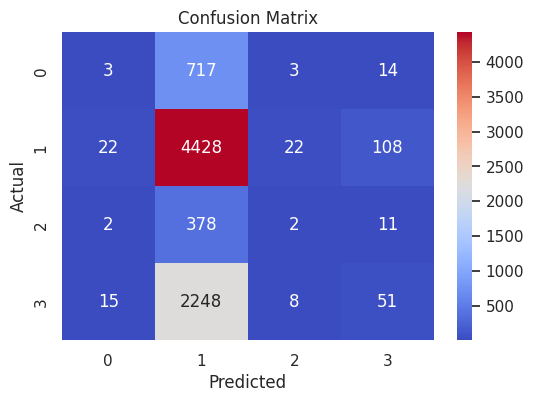

In [42]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


/tmp/ipython-input-611949424.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


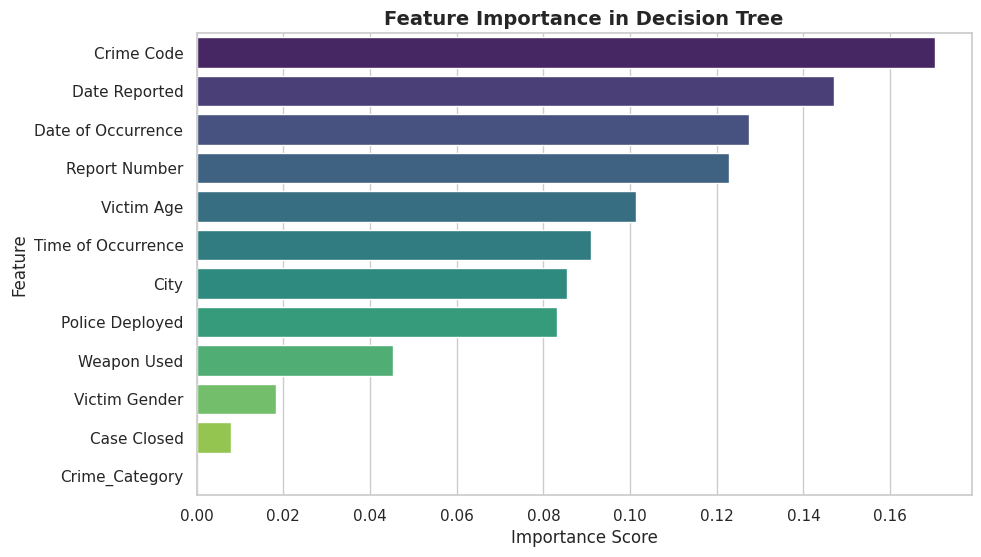

In [43]:
# --- Feature Importance ---
import pandas as pd

# Ensure X.columns is used as index since it contains the feature names after preprocessing
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title("Feature Importance in Decision Tree", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

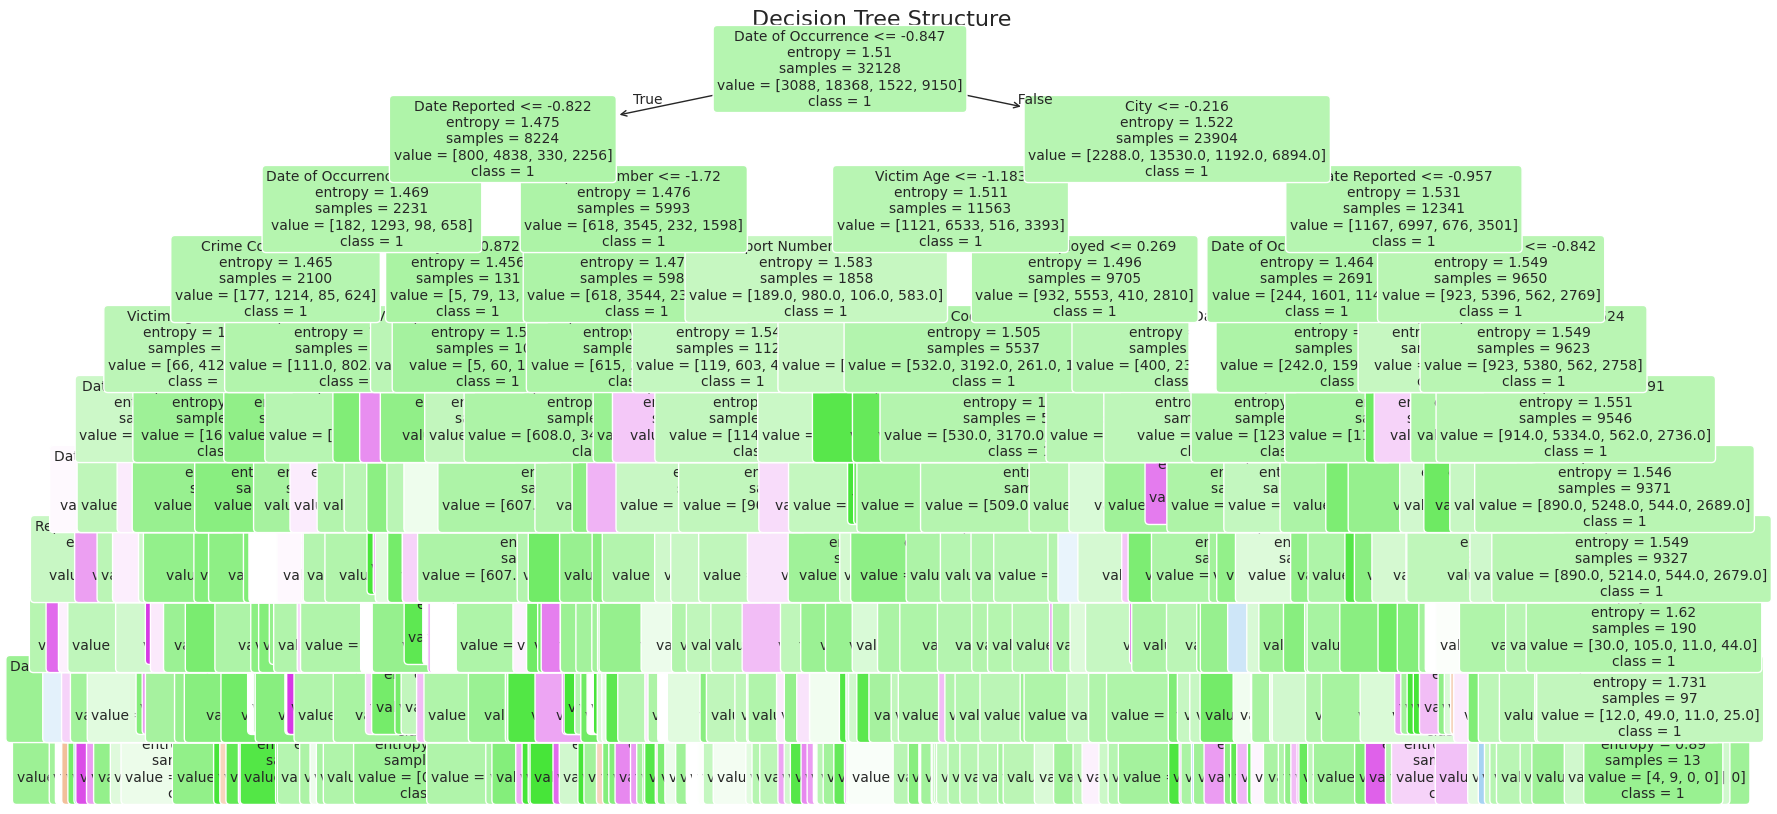

In [44]:
# --- Decision Tree Visualization ---
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=[str(c) for c in dt_model.classes_],
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure", fontsize=16)
plt.show()

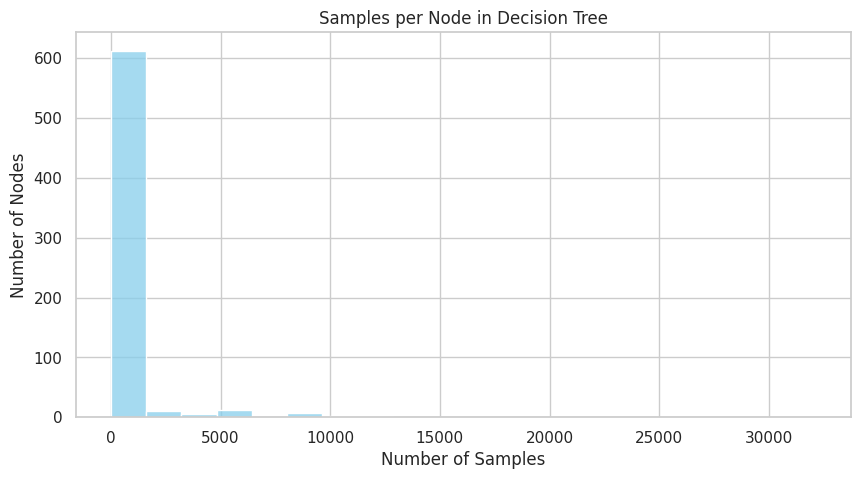

In [47]:
# Number of samples in each leaf
leaf_samples = dt_model.tree_.n_node_samples
plt.figure(figsize=(10,5))
sns.histplot(leaf_samples, bins=20, color='skyblue')
plt.title("Samples per Node in Decision Tree")
plt.xlabel("Number of Samples")
plt.ylabel("Number of Nodes")
plt.show()
